<a href="https://colab.research.google.com/github/mrayhanz/PCVK-Ganjil-2026/blob/main/week3_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Muhammad Rayhan Zamzami'
NIM = '244107020027'

N = int(NIM[-3:])
PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
    print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Rayhan Zamzami
NIM : 244107020027 | N = 27
b      : 47
a      : 1.0
c      : 37
gamma  : 1.15
bit    : 5
WAKTU : 2026-09-18 15:50:20 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 3570cede6807d021


Mounted at /content/drive/
 Mengubah tingkat kecerahan Citra 
 -------------------------------- 
 Masukkan Nilai kecerahan: 30


/tmp/ipykernel_4982/3439501978.py:31: RuntimeWarning: overflow encountered in scalar add
  original[y, x, c] + brightness, 0, 255


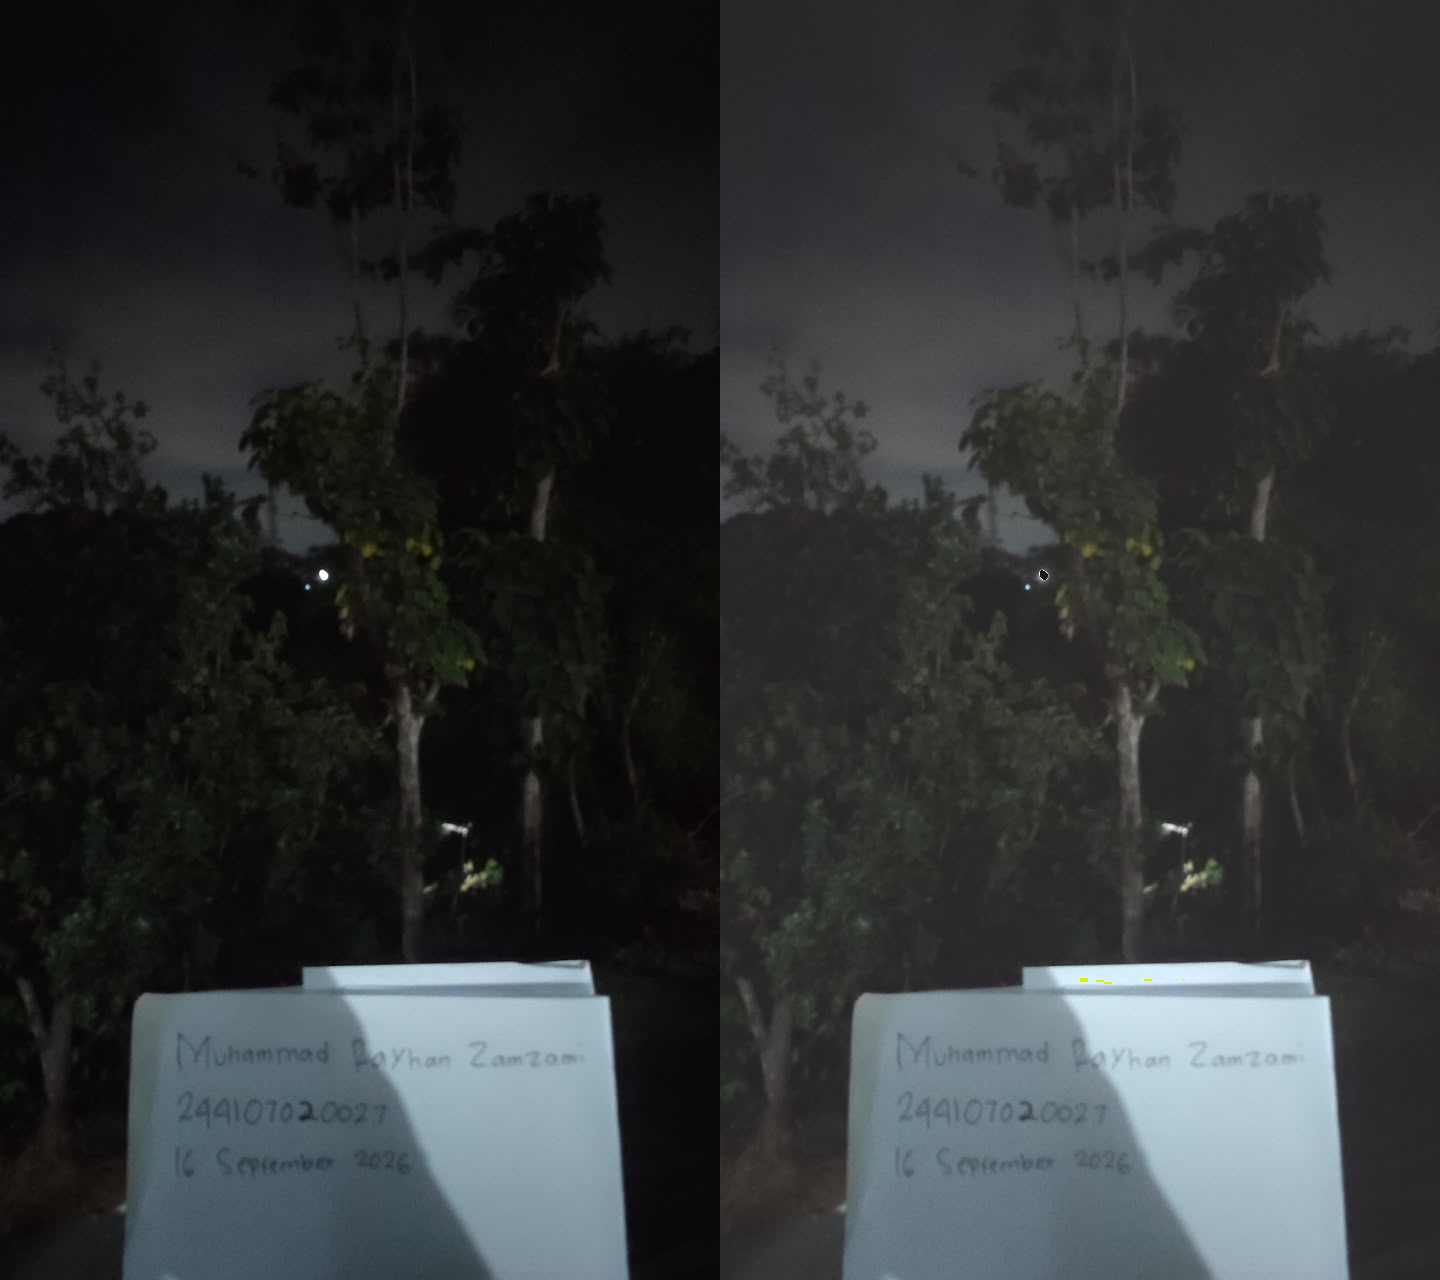

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
from google.colab import drive
drive.mount('/content/drive/')

from typing_extensions import final
print(' Mengubah tingkat kecerahan Citra ')
print(' -------------------------------- ')
try:
  brightness = int(input(' Masukkan Nilai kecerahan: '))
except ValueError:
    print ('Error, Not a Number')
    brightness = 0 #Default

original = cv.imread('/content/drive/MyDrive/PCVK/night.jpeg')

# Check if image loading was successful
if original is None:
    print("Error: Could not load image. Please check the path and ensure Drive is mounted correctly.")
else:
    brightness_image = np.zeros(original.shape, original.dtype)

    # akses per piksel
    # np.clip digunakan untuk melakukan truncate pixel (nilai dibatasi antara 0-255)
    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                brightness_image[y, x, c] = np.clip(
                    original[y, x, c] + brightness, 0, 255
                )

    # cara simple tanpa for loop
    # brightness_image = cv.convertScaleAbs(original, beta=brightness)

    final_image = cv.hconcat((original, brightness_image))

    cv2_imshow(final_image)

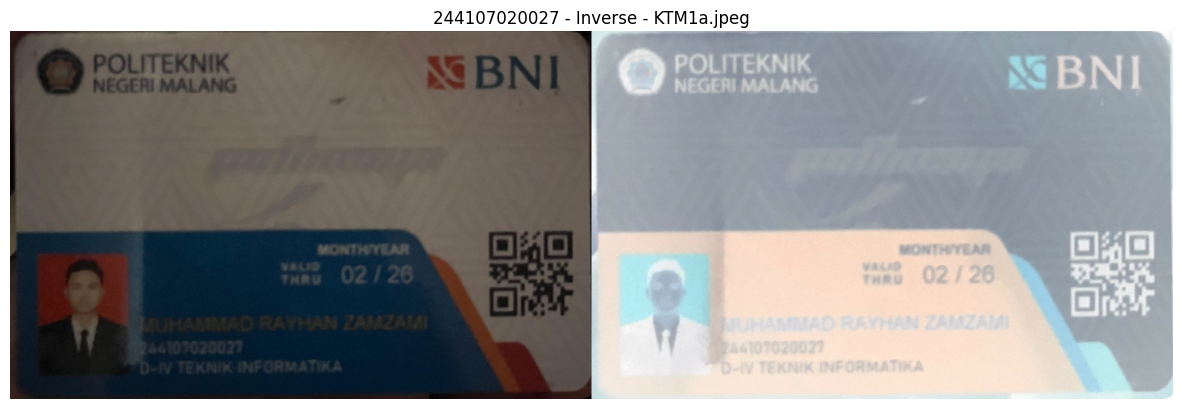

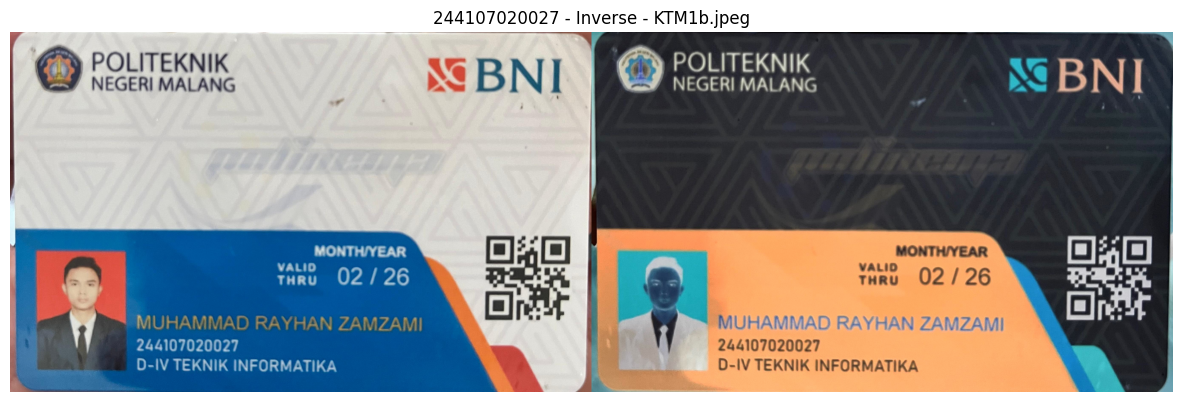

In [8]:
for nama_file in ['KTM1a.jpeg', 'KTM1b.jpeg']:
    original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')

    inverse = 255 - original  # inverse citra: g(x,y) = 255 - f(x,y)

    final_frame = cv.hconcat((original, inverse))

    plt.figure(figsize=(15,7))
    plt.title(NIM + ' - Inverse - ' + nama_file)
    plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

KTM1a tampak pucat dan berkabut karena kondisi ruangan gelap membuat sebagian besar piksel bernilai rendah. Setelah diinversi, piksel tersebut menjadi terang sehingga kontrasnya rendah. Sedangkan KTM1b memiliki intensitas piksel yang lebih beragam, sehingga setelah diinversi kontrasnya tetap terlihat.


Mengubah tingkat kecerahan dan kontras citra
--------------------------------
Masukkan nilai kecerahan (kosongkan utk pakai default 47): 
Masukkan nilai kontras (kosongkan utk pakai default 1.0): 1.5


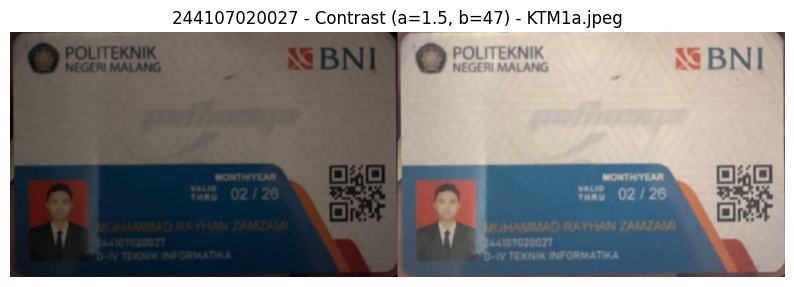

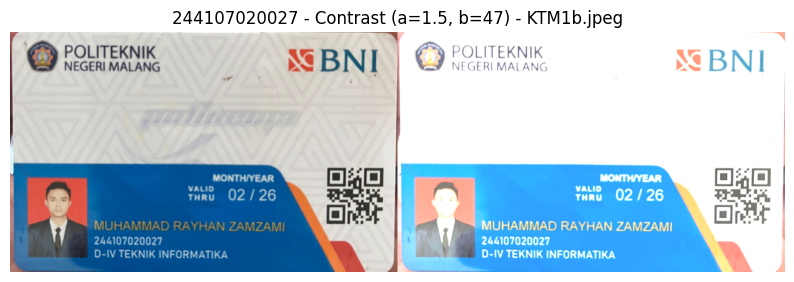

In [10]:
print('Mengubah tingkat kecerahan dan kontras citra')
print('--------------------------------')

try:
    brightness = int(
        input(
            f"Masukkan nilai kecerahan "
            f"(kosongkan utk pakai default {PARAM['b']}): ") or PARAM['b'])
except ValueError:
    print('Error, not a number — pakai default PARAM["b"]')
    brightness = PARAM['b']

try:
    kontras = float(
        input(
            f"Masukkan nilai kontras "
            f"(kosongkan utk pakai default {PARAM['a']}): ") or PARAM['a'])
except ValueError:
    print('Error, not a number — pakai default PARAM["a"]')
    kontras = PARAM['a']

for nama_file in ['KTM1a.jpeg', 'KTM1b.jpeg']:

    original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')

    contrast_image = np.zeros(original.shape,original.dtype)

    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                contrast_image[y, x, c] = np.clip(original[y, x, c] * kontras + brightness,0,255)

    final_frame = cv.hconcat((original, contrast_image))
    plt.figure(figsize=(10, 5))
    plt.title(f"{NIM} - Contrast (a={kontras}, b={brightness}) - {nama_file}")
    plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Transformasi logarithmic brightness
-----------------------------------
Masukkan nilai kecerahan (kosongkan utk pakai default 47): 55


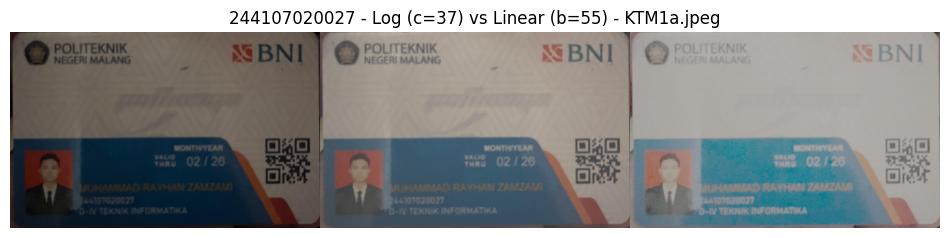

In [19]:
print('Transformasi logarithmic brightness')
print('-----------------------------------')

try:
    brightness = int(
        input(
            f"Masukkan nilai kecerahan "
            f"(kosongkan utk pakai default {PARAM['b']}): ") or PARAM['b'])
except ValueError:
    print('Error, not a number — pakai default PARAM["b"]')
    brightness = PARAM['b']

c_log = PARAM['c']
for nama_file in ['KTM1a.jpeg']:

    original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')
    brightness_image = np.zeros(original.shape,original.dtype)
    log_image = np.zeros(original.shape,np.float64)

    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for ch in range(original.shape[2]):
                pixel = float(original[y, x, ch])
                brightness_image[y, x, ch] = np.clip(pixel + brightness,0,255)
                log_image[y, x, ch] = np.clip(c_log * np.log(1 + pixel),0,255)

    log_image = log_image.astype(np.uint8)
    final_frame = cv.hconcat((original, brightness_image, log_image))
    plt.figure(figsize=(12, 5))
    plt.title(f"{NIM} - Log (c={c_log}) vs Linear (b={brightness}) - {nama_file}")
    plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Transformasi logaritmik digunakan untuk membantu memperjelas bagian gambar yang memiliki intensitas rendah.Metode ini dapat membuat area gelap lebih mudah terlihat dibandingkan peningkatan brightness secara linear, meskipun bagian yang sudah terang dapat mengalami clipping.

Transformasi grayscale averaging, lightness, dan luminance
----------------------------------------------------------


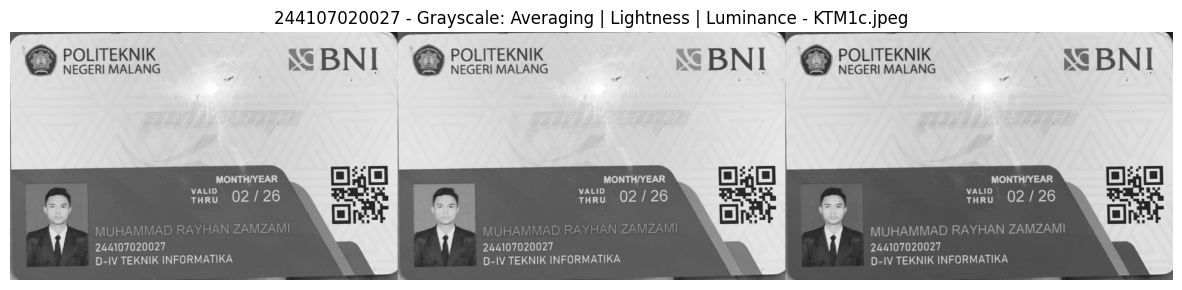

Averaging : mean = 165.89 std = 61.75
Lightness : mean = 167.32 std = 62.07
Luminance : mean = 160.46 std = 65.2


In [21]:
print('Transformasi grayscale averaging, lightness, dan luminance')
print('----------------------------------------------------------')

nama_file = 'KTM1c.jpeg'
original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')

h, w = original.shape[:2]

gray_avg = np.zeros((h, w), dtype=np.uint8)
gray_light = np.zeros((h, w), dtype=np.uint8)
gray_lum = np.zeros((h, w), dtype=np.uint8)

for y in range(h):
    for x in range(w):
        B = float(original[y, x, 0])
        G = float(original[y, x, 1])
        R = float(original[y, x, 2])

        gray_avg[y, x] = np.clip((R + G + B) / 3, 0, 255)
        gray_light[y, x] = np.clip((max(R, G, B) + min(R, G, B)) / 2, 0, 255)
        gray_lum[y, x] = np.clip(0.21 * R + 0.72 * G + 0.07 * B, 0, 255)

final_frame = cv.hconcat((gray_avg, gray_light, gray_lum))

plt.figure(figsize=(15, 5))
plt.title(f'{NIM} - Grayscale: Averaging | Lightness | Luminance - {nama_file}')
plt.imshow(final_frame, cmap='gray')
plt.axis('off')
plt.show()

print('Averaging : mean =', round(gray_avg.mean(), 2), 'std =', round(gray_avg.std(), 2))
print('Lightness : mean =', round(gray_light.mean(), 2), 'std =', round(gray_light.std(), 2))
print('Luminance : mean =', round(gray_lum.mean(), 2), 'std =', round(gray_lum.std(), 2))

Tiga metode grayscale digunakan untuk mengubah citra berwarna menjadi abu-abu. Averaging menggunakan rata-rata RGB, Lightness menggunakan nilai RGB tertinggi dan terendah, sedangkan Luminance memberikan bobot berbeda pada masing-masing kanal warna.

Menampilkan warna tertentu pada citra
-------------------------------------


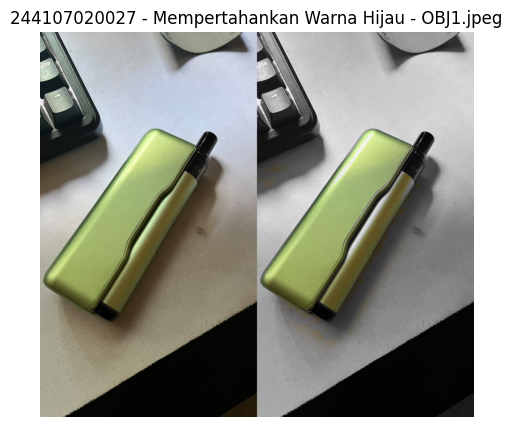

In [28]:
print('Menampilkan warna tertentu pada citra')
print('-------------------------------------')

nama_file = 'OBJ1.jpeg'
original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')

hsv = cv.cvtColor(original, cv.COLOR_BGR2HSV)

# Menentukan range warna hijau
lower = np.array([20, 80, 50])
upper = np.array([65, 255, 255])

mask = cv.inRange(hsv, lower, upper)

# Mengubah seluruh gambar menjadi grayscale
gray = cv.cvtColor(original, cv.COLOR_BGR2GRAY)
gray = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)

# Mengembalikan warna asli hanya pada area hijau
result = gray.copy()
result[mask > 0] = original[mask > 0]

final_frame = cv.hconcat((original, result))

plt.figure(figsize=(12, 5))
plt.title(f'{NIM} - Mempertahankan Warna Hijau - {nama_file}')
plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

Gamma Correction pada citra
---------------------------
Masukkan nilai gamma (kosongkan utk pakai default 1.15): 1.5


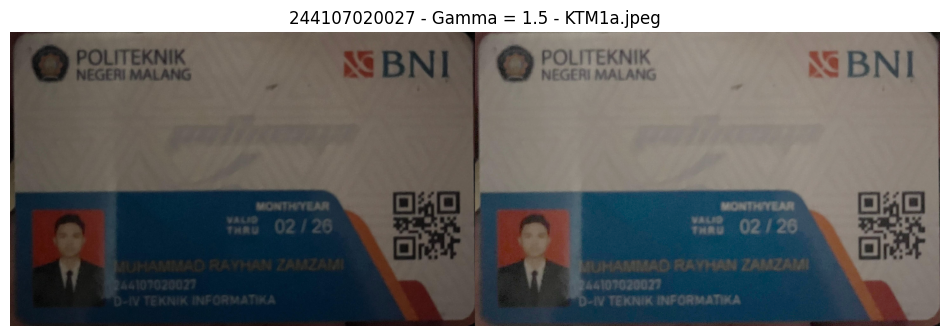

In [31]:
print('Gamma Correction pada citra')
print('---------------------------')

try:
    gamma = float(
        input(
            f"Masukkan nilai gamma (kosongkan utk pakai default {PARAM['gamma']}): "
        ) or PARAM['gamma']
    )
except ValueError:
    print('Error, not a number - pakai default PARAM["gamma"]')
    gamma = PARAM['gamma']

for nama_file in ['KTM1a.jpeg']:
    original = cv.imread(f'/content/drive/MyDrive/PCVK/{nama_file}')
    gamma_image = np.zeros(original.shape, original.dtype)

    for y in range(original.shape[0]):
        for x in range(original.shape[1]):
            for c in range(original.shape[2]):
                gamma_image[y, x, c] = np.clip(255 * ((original[y, x, c] / 255) ** (1 / gamma)),0,255)

    final_frame = cv.hconcat((original, gamma_image))

    plt.figure(figsize=(12, 5))
    plt.title(f'{NIM} - Gamma = {gamma} - {nama_file}')
    plt.imshow(cv.cvtColor(final_frame, cv.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

Nilai gamma setiap mahasiswa bisa berbeda walaupun objeknya sama karena kondisi pencahayaan, tingkat kegelapan, dan intensitas piksel pada foto masing-masing berbeda. Oleh karena itu, diperlukan nilai gamma yang berbeda untuk mendapatkan hasil citra yang paling sesuai.

Simulasi Image Depth pada Citra Pribadi
---------------------------------------
Masukkan bit depth tujuan (1-8): 4
Bit depth awal : 8 bit
Bit depth tujuan: 4 bit
Jumlah level   : 16


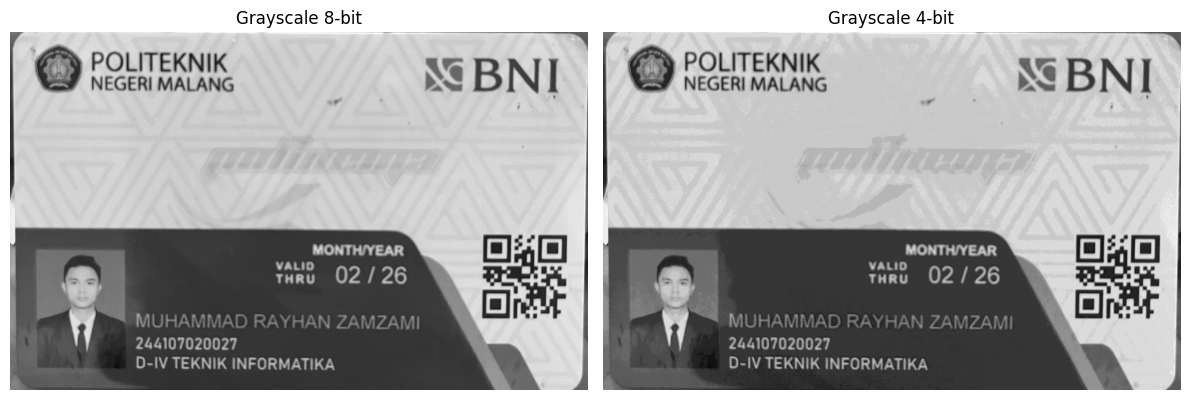

In [33]:
print('Simulasi Image Depth pada Citra Pribadi')
print('---------------------------------------')

try:
    bit_depth = int(input('Masukkan bit depth tujuan (1-8): '))

    if bit_depth < 1 or bit_depth > 8:
        print('Error, bit depth harus antara 1 sampai 8')
    else:
        original = cv.imread(f'/content/drive/MyDrive/PCVK/KTM1b.jpeg',cv.IMREAD_GRAYSCALE)

        level = 255 / (pow(2, bit_depth) - 1)

        depth_image = np.round(original / level) * level

        depth_image = depth_image.astype(np.uint8)

        print(f'Bit depth awal : 8 bit')
        print(f'Bit depth tujuan: {bit_depth} bit')
        print(f'Jumlah level   : {pow(2, bit_depth)}')

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(original, cmap='gray')
        plt.title('Grayscale 8-bit')
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(depth_image, cmap='gray')
        plt.title(f'Grayscale {bit_depth}-bit')
        plt.axis('off')

        plt.tight_layout()
        plt.show()

except ValueError:
    print('Error, not a number')

Denoising
---------
Jumlah gambar : 100
10 gambar PSNR = 19.74 dB
20 gambar PSNR = 19.84 dB
40 gambar PSNR = 19.89 dB
80 gambar PSNR = 19.92 dB
100 gambar PSNR = 19.92 dB


<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

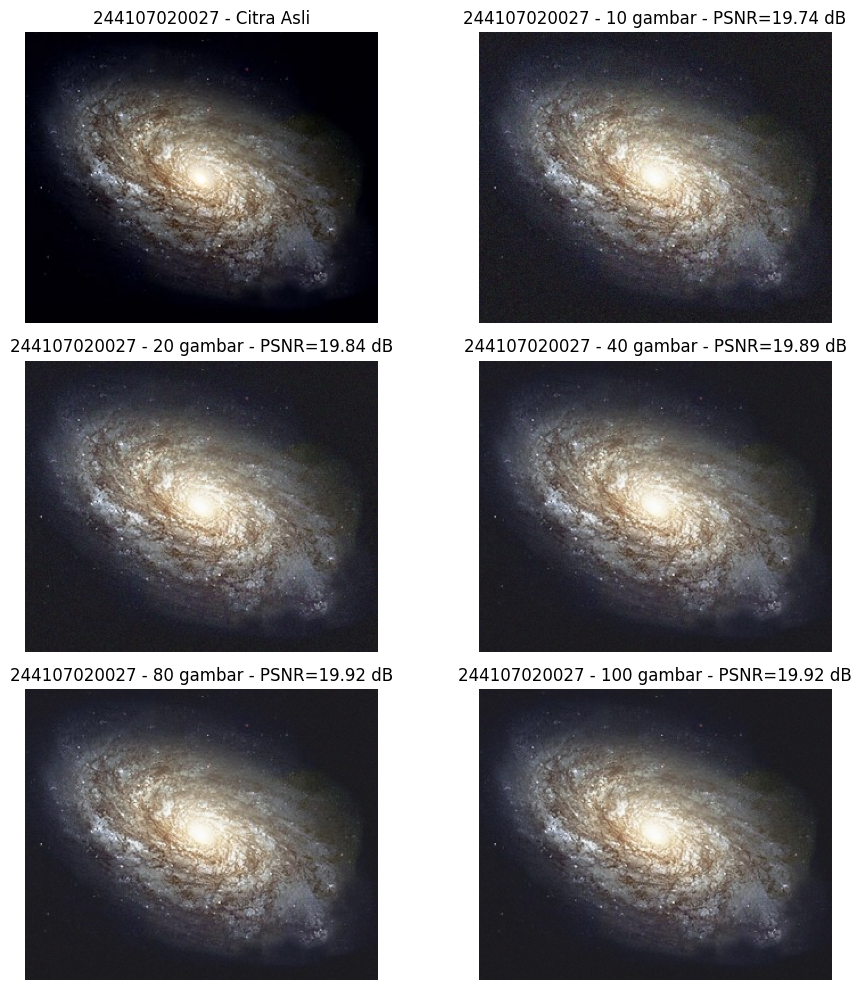

In [39]:
import glob

print('Denoising')
print('---------')

cv_img = []

for img in sorted(glob.glob('/content/drive/MyDrive/PCVK/noises/*.jpg')):
    n = cv.imread(img)
    cv_img.append(n)

print('Jumlah gambar :', len(cv_img))

galaxy = cv.imread(f'/content/drive/MyDrive/PCVK/galaxy.jpg')

def average_denoising(images, jumlah):
    avg = np.zeros(images[0].shape, dtype=np.float64)

    for i in range(jumlah):
        avg += images[i]

    avg = avg / jumlah

    return avg.astype(np.uint8)


def hitung_psnr(img1, img2):
    img1 = img1.astype(np.float64)
    img2 = img2.astype(np.float64)

    mse = np.mean((img1 - img2) ** 2)

    if mse == 0:
        return 100

    return 20 * np.log10(255.0 / np.sqrt(mse))
    jumlah_list = [10, 20, 40, 80, 100]

hasil_list = []
psnr_list = []

for jumlah in jumlah_list:
    hasil = average_denoising(cv_img, jumlah)
    psnr = hitung_psnr(galaxy, hasil)

    hasil_list.append(hasil)
    psnr_list.append(psnr)

    print(f'{jumlah} gambar PSNR = {psnr:.2f} dB')
    plt.figure(figsize=(10, 10))

plt.subplot(3, 2, 1)
plt.imshow(cv.cvtColor(galaxy, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Citra Asli')
plt.axis('off')

for i in range(len(hasil_list)):
    hasil_rgb = cv.cvtColor(hasil_list[i], cv.COLOR_BGR2RGB)

    plt.subplot(3, 2, i + 2)
    plt.imshow(hasil_rgb)
    plt.title(
        f'{NIM} - {jumlah_list[i]} gambar - PSNR={psnr_list[i]:.2f} dB'
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

Peningkatan jumlah citra tidak selalu meningkatkan PSNR secara signifikan. Mulai 80 citra, peningkatannya cenderung kecil.

Kesimpulan: semakin banyak citra, noise semakin berkurang, tetapi setelah jumlah tertentu peningkatan kualitasnya tidak terlalu besar.

Image Masking untuk penyamaran pribadi
--------------------------------------


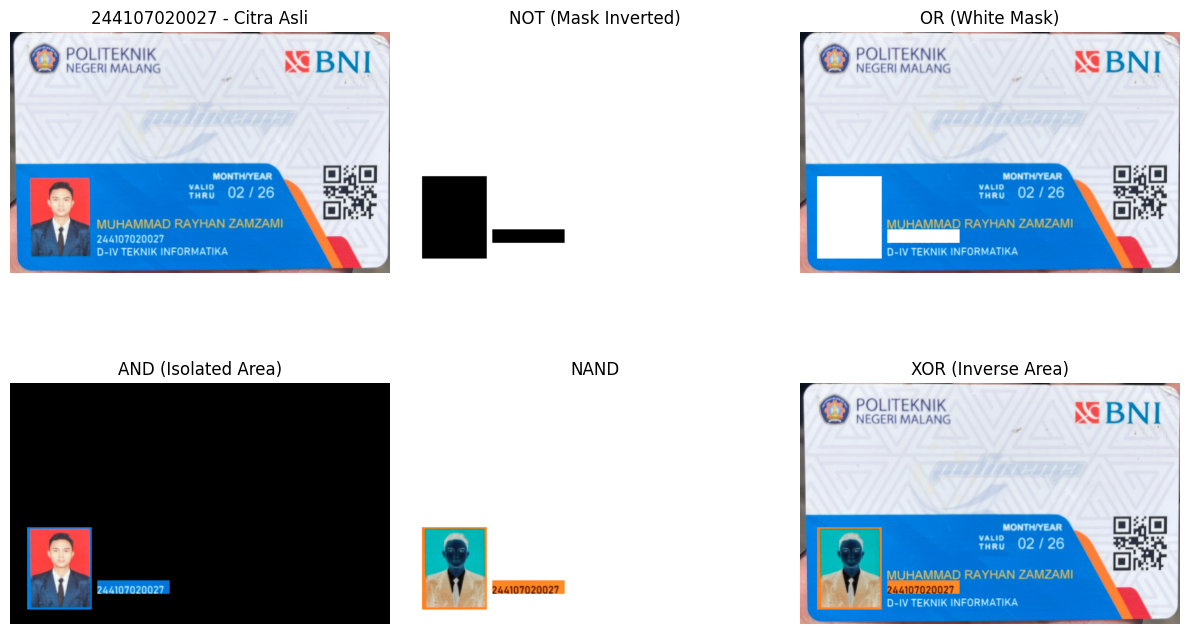

In [67]:
print('Image Masking untuk penyamaran pribadi')
print('--------------------------------------')

h, w = original.shape[:2]

mask = np.zeros((h, w), dtype=np.uint8)

# 1. Mask area FOTO WAJAH (kiri-bawah kartu)
x0, x1 = int(0.045*w), int(0.215*w)
y0, y1 = int(0.60*h), int(0.94*h)
cv.rectangle(mask, (x0, y0), (x1, y1), 255, -1)

# 2. Mask area NIM saja (baris "244107020027")
x0, x1 = int(0.23*w), int(0.42*w)
y0, y1 = int(0.82*h), int(0.875*h)
cv.rectangle(mask, (x0, y0), (x1, y1), 255, -1)

hasil_and = cv.bitwise_and(original, original, mask=mask)
hasil_not = cv.bitwise_not(mask)
mask_bgr  = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
hasil_or  = cv.bitwise_or(original, mask_bgr)
hasil_nand = cv.bitwise_not(hasil_and)
hasil_xor  = cv.bitwise_xor(original, mask_bgr)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(f'{NIM} - Citra Asli')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(hasil_not, cmap='gray')
plt.title('NOT (Mask Inverted)')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv.cvtColor(hasil_or, cv.COLOR_BGR2RGB))
plt.title('OR (White Mask)')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv.cvtColor(hasil_and, cv.COLOR_BGR2RGB))
plt.title('AND (Isolated Area)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(cv.cvtColor(hasil_nand, cv.COLOR_BGR2RGB))
plt.title('NAND')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(cv.cvtColor(hasil_xor, cv.COLOR_BGR2RGB))
plt.title('XOR (Inverse Area)')
plt.axis('off')

plt.tight_layout()

Perbaikan Foto Malam
--------------------


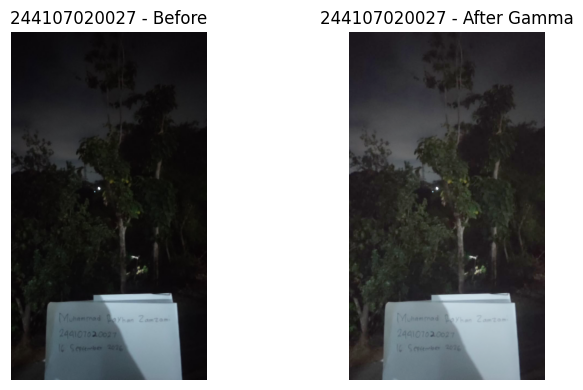

Metode        : Gamma Correction
Gamma terbaik : 1.5


In [71]:
print('Perbaikan Foto Malam')
print('--------------------')

nama_file = 'night.jpeg'

original = cv.imread(
    f'/content/drive/MyDrive/PCVK/{nama_file}'
)

gamma = 1.5

gamma_image = np.zeros(
    original.shape,
    dtype=np.uint8
)

for y in range(original.shape[0]):
    for x in range(original.shape[1]):
        for c in range(original.shape[2]):
            gamma_image[y, x, c] = np.clip(
                255 * ((original[y, x, c] / 255) ** (1 / gamma)),
                0,
                255
            )

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Before')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(gamma_image, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - After Gamma')
plt.axis('off')

plt.tight_layout()
plt.show()

print('Metode        : Gamma Correction')
print('Gamma terbaik :', gamma)

Metode yang dipilih

Metode yang digunakan adalah Gamma Correction dengan nilai gamma 1,5.

Alasan pemilihan

Metode ini dipilih karena dapat meningkatkan kecerahan pada bagian foto yang gelap sehingga detail gambar lebih mudah terlihat.

Menentukan parameter terbaik

Beberapa nilai gamma dibandingkan. Nilai 1,5 dipilih karena menghasilkan gambar yang lebih terang tetapi detail dan kontrasnya masih cukup terlihat.

Before–After

Before: Foto malam terlihat gelap dan beberapa detail sulit terlihat.
After: Foto menjadi lebih terang sehingga detail pada bagian gelap lebih mudah terlihat.